<a href="https://colab.research.google.com/github/ablasve/Mini-Proyecto-Asistente-Multimodal-de-Salud/blob/main/FaseB_Qwen2VL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASE B: Procesamiento Multimodal de la información

En esta fase vamos a dedicarnos a lo central del proyecto: el procesamiento de la información de entrada (inputs) que puede tener formato de texto, imagen o audio, para después proporcionar una respuesta adecuada a las necesidades especificadas mediante modelos preentrenados de IA.

**Contenidos**<a id='toc0_'></a>   

[Librerías necesarias y funciones previas](#toc1)

[Grabadora de voz para Google Colab](#toc2)

[Opciones del asistente](#toc3)
- [Registrar medicamentos mediante imágenes](#toc3_1)

- [Registrar medicamentos mediante texto](#toc3_2)

- [Resumen de los tratamientos](#toc3_3)

- [Preguntas por voz](#toc3_4)


<!-- vscode-jupyter-toc-config
    numbering=false
    anchor=true
    flat=false
    minLevel=1
    maxLevel=6
    /vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1'></a>[0. Librerías necesarias y funciones previas](#toc0_)

In [1]:
# Para no tener problemas importando tantos modelos:
!pip install -q bitsandbytes
from transformers import BitsAndBytesConfig

# Para grabar AUDIO:
!pip install openai-whisper -q
import whisper
from google.colab import output
from base64 import b64decode

# Para reproducir AUDIO:
!pip install edge-tts -q
import edge_tts
import asyncio
from IPython.display import Audio, display

# Para administrar ARCHIVOS:
import json
import os
from google.colab import files

# Para administrar IMÁGENES:
import PIL.Image

# Para pasar de VOZ a AUDIO:
from whisper import load_model
model_whisper = load_model("small") # Cargamos el modelo Whisper

# Para pasar de IMAGEN a TEXTO
!pip install -q transformers accelerate qwen-vl-utils

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
import torch
torch.cuda.empty_cache()

id_model = "Qwen/Qwen2-VL-2B-Instruct"

# Cargamos el procesador de imágenes
processor = AutoProcessor.from_pretrained(id_model)

# Configuración para ahorrar memoria (4 bits)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32
)

# Cargamos el modelo
model = Qwen2VLForConditionalGeneration.from_pretrained(
    id_model,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Modelo cargado con éxito")

from transformers import AutoModelForCausalLM, AutoTokenizer

# Cargamos el modelo de Texto puro para EL RESUMEN HORARIO
id_model_texto = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer_texto = AutoTokenizer.from_pretrained(id_model_texto)
model_texto = AutoModelForCausalLM.from_pretrained(
    id_model_texto,
    quantization_config=bnb_config,
    device_map="auto"
)
print("Modelo de TEXTO cargado con éxito")

#función auxiliar para tener la fecha en español
from datetime import datetime

def obtener_fecha_hoy_formato_json():
    # Diccionario con las abreviaturas exactas en español
    meses_abrev = [
        "ene", "feb", "mar", "abr", "may", "jun",
        "jul", "ago", "sep", "oct", "nov", "dic"
    ]

    hoy = datetime.now()

    # Formateamos el día para que siempre tenga 2 cifras (ej. 05 en vez de 5)
    dia = f"{hoy.day:02d}"
    mes = meses_abrev[hoy.month - 1]
    anio = hoy.year

    # Resultado final: ej. "26-mar-2026"
    return f"{dia}-{mes}-{anio}"


# Función para generar y reproducir el audio
async def generar_voz(texto):
    # Elegimos la voz: 'es-ES-ElviraNeural' (Mujer, España, muy clara)
    # O 'es-ES-AlvaroNeural' si prefieres hombre.
    VOICE = "es-ES-ElviraNeural"
    OUTPUT_FILE = "respuesta_asistente.mp3"

    communicate = edge_tts.Communicate(texto, VOICE, rate="-10%") # rate="-10%" si la quieres más lenta
    await communicate.save(OUTPUT_FILE)

    # Reproducir en Colab
    display(Audio(OUTPUT_FILE, autoplay=True))

# Forma de ejecutar la función:
# await generar_voz(respuesta_texto)

# Para cargar el HISTORIAL DEL USUARIO:
def cargar_memoria():
    if os.path.exists("memoria_salud.json"):
        with open("memoria_salud.json", "r") as f:
            return json.load(f)
    else:
        # Si no existe, creamos un perfil vacío
        return {"nombre": None, "medicinas": [], "ultimas_adiciones": [], "resumen": []}

def guardar_memoria(datos):
    with open("memoria_salud.json", "w") as f:
        json.dump(datos, f, indent=4)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 47.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


100%|████████████████████████████████████████| 461M/461M [00:01<00:00, 323MiB/s]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 21.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo de TEXTO cargado con éxito


In [ ]:
# Inicializamos la memoria al empezar así:
# memoria = cargar_memoria()


## <a id='toc2'></a>[1. Grabadora de voz para Google Colab](#toc0_)

Como Colab vive en la nube, no puede acceder directamente al micrófono con Python, por lo que necesitaremos definir una función puente, `grabar_audio`, con la que podremos recabar la información deseada a través del micrófono de los usuarios.

In [2]:
# Código JavaScript para grabar audio desde el navegador
RECORD_JS = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  const recorder = new MediaRecorder(stream)
  const chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    const blob = new Blob(chunks)
    const text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

def grabar_audio(segundos=5):
    print(f"Escuchando durante {segundos} segundos...")
    display(output.eval_js(RECORD_JS))
    audio_b64 = output.eval_js(f"record({segundos*1000})")
    audio_bytes = b64decode(audio_b64.split(',')[1])
    with open("audio_usuario.wav", "wb") as f:
        f.write(audio_bytes)
    return "audio_usuario.wav"


## <a id='toc3'></a>[2. Opciones del asistente](#toc0_)

### <a id='toc3_1'></a>[2.1. Registrar medicamentos mediante imágenes](#toc0_)

En este primer apartado abordaremos la primera opción que ofrece el asistente: introducir los medicamentos mediante una foto de la receta o del envase. Para llevar a cabo esta tarea de forma local, sin depender de cuotas ni APIs externas, usaremos el modelo multimodal de código abierto Qwen2-VL. Este modelo de visión-lenguaje se ejecutará directamente sobre la GPU de nuestro entorno.

Primero desarrollaremos la función `analizar_receta`, que tiene como argumentos de entrada la ruta a la imagen y el histórico del usuario. Mediante un prompt específico pediremos al modelo que analice la imagen y proceda de la siguiente manera:

- Si detecta algún medicamento no presente en el historial, o alguno que ya estaba registrado pero cuyos campos hayan cambiado (por ejemplo, una nueva pauta para un medicamento habitual), unificará la información y nos devolverá un objeto JSON con dos elementos: una lista con todos los medicamentos y otra lista solo con las nuevas adiciones detectadas en la foto.
- Si no se detecta ningún tratamiento nuevo respecto al historial, devolverá simplemente _None_.

Para finalizar el proceso, la función `registrar_en_memoria` se encargará de actualizar y guardar los datos consolidados en la base de datos del usuario.

In [76]:
import re, json

min_pixels = 256 * 28 * 28
#max_pixels = 480 * 28 * 28
# Aumentamos el máximo a casi 1 millón de píxeles para que lea el texto nítido
max_pixels = 1280 * 28 * 28

def generar_resumen(datos_nuevos, memoria):
  # Mantenemos tu prompt en inglés, solo inyectamos los datos extraídos en lugar de la imagen
  prompt = f"""
  Extract prescription information from the following data and return a short, plain text explaining the medications, its dosages, its ending dates
  and its indications. It must be in Spanish and be comprehensible for elder people. Contrast and join this info with the history.

  Extracted data:
  {datos_nuevos}

  History:
  {memoria.get("resumen", "")}
  """

  mensajes = [
          {
              "role": "user",
              "content": prompt
          }
      ]

  print("El modelo de texto está redactando el resumen para el paciente...")

  # Usamos el tokenizer de texto en lugar del procesador de visión
  text = tokenizer_texto.apply_chat_template(mensajes, tokenize=False, add_generation_prompt=True)

  inputs = tokenizer_texto(
      [text],
      return_tensors="pt"
  ).to("cuda")

  with torch.no_grad():
      # Usamos model_texto en lugar del modelo visual
      generated_ids = model_texto.generate(**inputs, max_new_tokens=1024)

  generated_ids_trimmed = [
      out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
  ]

  texto_respuesta = tokenizer_texto.batch_decode(
      generated_ids_trimmed,
      skip_special_tokens=True
  )[0].strip()

  del inputs
  del generated_ids
  torch.cuda.empty_cache()

  return texto_respuesta


def analizar_receta(ruta_imagen, memoria, resumen = False):
  prompt = f"""
Extract prescription information from the image and return ONLY valid JSON.
The output must be in Spanish.

Format:
{{
  "lista_completa": [
    {{
      "nombre": "",
      "dosis": "",
      "pautas_toma": "",
      "fin": ""
    }}
  ],
  "adiciones": []
}}

Rules:
- Only JSON
- Escape all internal quotes
- All fields must be strings
- Keep Spanish text in output
- "pautas_toma" field: short treatment instructions normally BETWEEN "nombre" and "dosis". Use "" if missing.
- STRICTLY FORBIDDEN: Do not include info like legal texts, medical appointment reminders, prices, VAT/IVA, warnings about medicine accumulation, or prescription expiration info.
- "fin" = treatment end date

History (ignore for extraction):
{memoria.get('medicinas', [])}
"""

  mensajes = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": ruta_imagen},
                {"type": "text", "text": prompt},
            ],
        }
    ]

  try:
      print("El modelo local está leyendo la imagen...")

      text = processor.apply_chat_template(mensajes, tokenize=False, add_generation_prompt=True)
      image_inputs, video_inputs = process_vision_info(mensajes)

      inputs = processor(
          text=[text],
          images=image_inputs,
          videos=video_inputs,
          padding=True,
          return_tensors="pt",
          min_pixels=min_pixels,
          max_pixels=max_pixels
      ).to("cuda")

      with torch.no_grad():
          generated_ids = model.generate(**inputs, max_new_tokens=1024)

      generated_ids_trimmed = [
          out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
      ]

      del inputs
      del generated_ids
      torch.cuda.empty_cache()

      texto_respuesta = processor.batch_decode(
          generated_ids_trimmed,
          skip_special_tokens=True
      )[0].strip()

      # Extraer JSON
      match = re.search(r'\{.*\}', texto_respuesta, re.DOTALL)
      if not match:
          print("No hay JSON válido en la respuesta")
          print(texto_respuesta)
          return None

      json_text = match.group(0)

      # Escapar comillas internas
      json_text = re.sub(r'(\w)"(\w)', r'\1\\"\\2', json_text)

      datos_json = json.loads(json_text)

      lista = datos_json.get("lista_completa", [])
      adiciones = datos_json.get("adiciones", [])

      if not lista:
          return None

      if resumen:
        resumen = generar_resumen(ruta_imagen, memoria)
        return [lista, adiciones], resumen

      return [lista, adiciones]

  except Exception as e:
      print("Error:", e)
      return None

In [32]:
def registrar_en_memoria(nuevos_datos, resumen=False):
    memoria = cargar_memoria()
    memoria.setdefault('medicinas', [])
    memoria.setdefault('ultimas_adiciones', [])

    lista_nuevas = nuevos_datos[0]  # recetas extraídas
    ultimas_adiciones = []

    for receta in lista_nuevas:
        # Identificador único: nombre + dosis + fecha fin
        key = (receta['nombre'], receta['dosis'], receta['fin'])
        # comprobar si ya existe
        existe = any(
            (m['nombre'], m['dosis'], m['fin']) == key
            for m in memoria['medicinas']
        )
        if not existe:
            memoria['medicinas'].append(receta)
            ultimas_adiciones.append(receta)

    memoria['ultimas_adiciones'] = ultimas_adiciones

    if resumen:
      memoria["resumen"] = resumen

    guardar_memoria(memoria)
    return memoria

Probamos las funciones con las recetas de ejemplo `Recetas_Fulanita1.jpeg` y `Recetas_Fulanita.jpeg`.



In [66]:
# primero inspeccionamos memoria (debería estar vacía)
memoria = cargar_memoria()

# visualizamos las medicinas y cuáles se han introducido las últimas
print("Historial:", memoria.get('medicinas', []))
print("Últimas:", memoria.get('ultimas_adiciones', []))

# ==========================================
# PRUEBA RECETA 1
# ==========================================
print("\n--- Analizando Receta 1 ---")
medicacion1 = analizar_receta("Recetas_Fulanita1.jpeg", memoria)

if medicacion1 is not None:
    memoria = registrar_en_memoria(medicacion1)
    print("Receta 1 guardada con éxito")
else:
    print("No se ha guardado la receta 1 porque la IA no encontró datos válidos o devolvió un error.")

# visualizamos la base de datos actualizada
print("Historial:", memoria.get('medicinas', []))
print("Últimas:", memoria.get('ultimas_adiciones', []))

# ==========================================
# PRUEBA RECETA 2
# ==========================================
print("\n--- Analizando Receta 2 ---")
medicacion2 = analizar_receta("Recetas_Fulanita.jpeg", memoria)

# EL ESCUDO DE SEGURIDAD VITAL:
if medicacion2 is not None:
    memoria = registrar_en_memoria(medicacion2)
    print("Receta 2 guardada con éxito")
else:
    print("No se ha guardado la receta 2 porque la IA no encontró datos nuevos o devolvió un error.")

# visualizamos la base de datos actualizada
print("Historial:", memoria.get('medicinas', []))
print("Últimas:", memoria.get('ultimas_adiciones', []))

Historial: []
Últimas: []

--- Analizando Receta 1 ---
El modelo local está leyendo la imagen...
Receta 1 guardada con éxito
Historial: [{'nombre': 'AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]', 'dosis': '1 COMPRIMIDO cada 8 horas durante 7 días', 'pautas_toma': '', 'fin': '26-mar-2026'}]
Últimas: [{'nombre': 'AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]', 'dosis': '1 COMPRIMIDO cada 8 horas durante 7 días', 'pautas_toma': '', 'fin': '26-mar-2026'}]

--- Analizando Receta 2 ---
El modelo local está leyendo la imagen...
Receta 2 guardada con éxito
Historial: [{'nombre': 'AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO]', 'dosis': '1 COMPRIMIDO cada 8 horas durante 7 días', 'pautas_toma': '', 'fin': '26-mar-2026'}, {'nombre': 'FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA]', 'dosis': '1 COMPRIMIDO EFERVESCENTE cada día

In [67]:
# visualizamos la base de datos actualizada, para ver si no ha duplicado la info
for dic in memoria['medicinas']:
    print(f'--- {dic.get("nombre", "")} ---')
    print(f'Dosis: {dic.get("dosis", "")}')
    print(f'Instrucciones: {dic.get("pautas_toma", "")}')
    print(f'Fecha de fin: {dic.get("fin", "")}\n')

print('Últimas medicinas añadidas:')
for med in memoria['ultimas_adiciones']:
  print(f'- {med}')
if not memoria['ultimas_adiciones']:
  print('No hay medicinas añadidas recientemente')

--- AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] ---
Dosis: 1 COMPRIMIDO cada 8 horas durante 7 días
Instrucciones: 
Fecha de fin: 26-mar-2026

--- FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] ---
Dosis: 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días
Instrucciones: 
Fecha de fin: 26-mar-2026

--- PARACETAMOL 1000 MG / 40 COMPRIMIDOS ---
Dosis: 1 COMPRIMIDO cada día durante 7 días
Instrucciones: 
Fecha de fin: 26-mar-2026

--- XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] ---
Dosis: 1 COMPRIMIDO cada día durante 7 días
Instrucciones: 
Fecha de fin: 26-mar-2026

--- OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] ---
Dosis: 1 COMPRIMIDO cada día durante 30 días
Instrucciones: 
Fecha de fin: 26-mar-2026

--- CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES ---
Dosis: 1 COMPRIMIDO cada día CRÓNICO
Instrucciones: 
Fecha de fin: 01-oct-2026

Últim

Vemos que no nos ha hecho mucho caso con no incluir texto legal o de precios con el AUGMENTINE, pero lo ha hecho bien para el resto de argumentos y medicamentos, mejor que sobre información que que se deje por incluir.

(np.float64(-0.5), np.float64(1759.5), np.float64(2415.5), np.float64(-0.5))

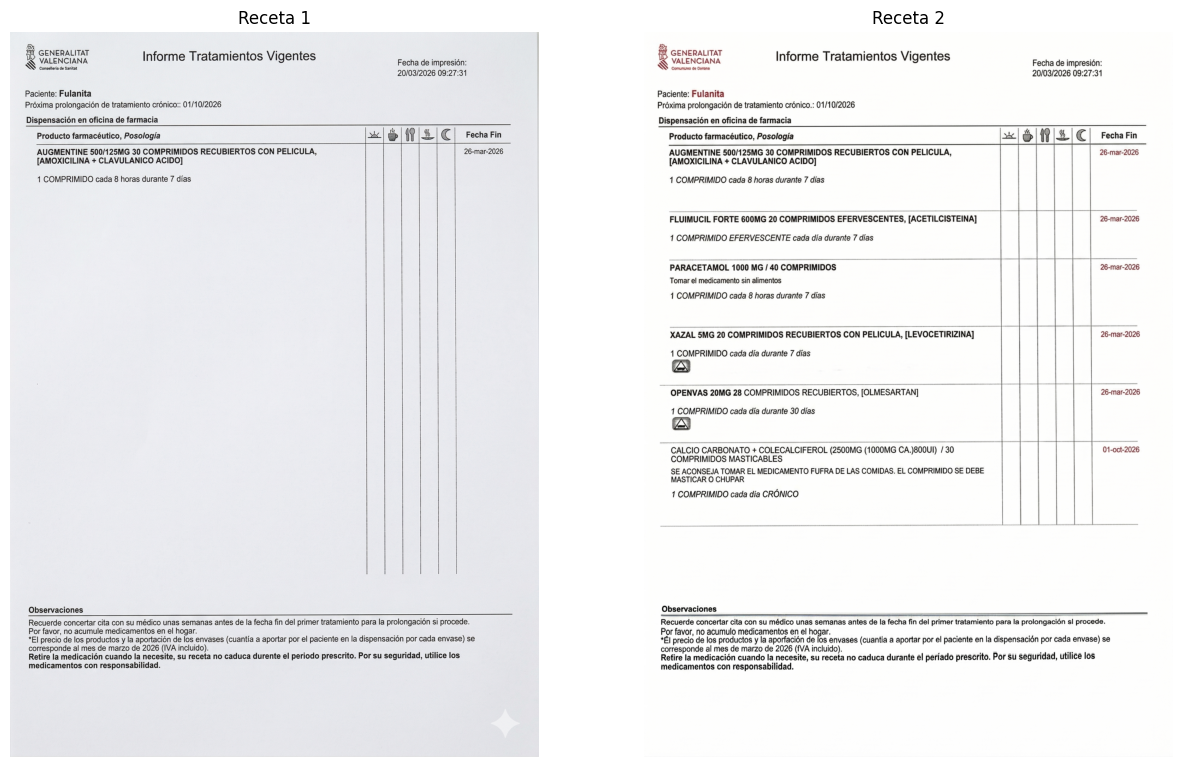

In [68]:
import matplotlib.pyplot as plt
%matplotlib inline

# Cargar las imágenes desde la ruta local de Colab
img1 = PIL.Image.open('/content/Recetas_Fulanita1.jpeg')
img2 = PIL.Image.open('/content/Recetas_Fulanita.jpeg')

# mostrarlas juntas
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

axes[0].imshow(img1)
axes[0].set_title("Receta 1")
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title("Receta 2")
axes[1].axis('off')


Vemos que lo ha hecho perfectamente, ya que la primera receta que le hemos proporcionado era la misma que la segunda, a excepción de la cantidad de medicamentos que hemos dejado visibles. Aunque el primer medicamento estuviese repetido, al procesar la segunda receta el modelo ha sido capaz de identificarlo y en el archivo de memoria final solo hemos obtenido la información deseada, sin rastro de duplicados.

Programemos y veamos si funciona correctamente la función para ejecutar la opción 1, a la cual le volveremos a pasar la segunda receta. La función `ejecutar_opcion_1` pide al usuario que suba la imagen, usa `analizar_receta` para procesar la información y, dependiendo del resultado que proporcione, o bien informa de que ha actualizado el historial, o de que no había necesidad de hacerlo y lo muestra para que el usuario pueda comprobar que todos los medicamentos están registrados.

In [78]:
async def ejecutar_opcion_1(memoria):
    print("\n[Asistente]: Por favor, sube la foto de tu receta o medicina.")
    await generar_voz("Por favor, sube la foto de tu receta o medicina.")

    # Abre el selector de archivos de Colab
    subido = files.upload()

    if subido:
        nombre_archivo = list(subido.keys())[0]

        print("--- Analizando imagen... ---")
        datos_extraidos, resu = analizar_receta(nombre_archivo, memoria, resumen=True)

        if datos_extraidos:
          # Guardamos en la memoria JSON
          memoria_actualizada = registrar_en_memoria(datos_extraidos,resumen=resu)

          # Extraemos las últimas adiciones que sí se guardaron
          ultimas = memoria_actualizada.get('ultimas_adiciones', [])

          if ultimas:
              nombres = [med['nombre'] for med in ultimas]
              if len(nombres) == 1:
                  confirmacion = f"He leído y guardado correctamente: {nombres[0]}. Ya está en tu lista de recordatorios."
              else:
                  confirmacion = f"He leído y guardado correctamente: {', '.join(nombres[:-1])} y {nombres[-1]}. Ya están en tu lista de recordatorios."
          else:
              confirmacion = "No se han añadido nuevas medicinas; ya estaban en tu lista."

          print(f"\n[Asistente]: {confirmacion}")
          await generar_voz(confirmacion)

          # Mostramos cómo queda la lista visualmente
          mostrar_recordatorios(memoria_actualizada)

          # Borramos el archivo tras procesarlo
          if os.path.exists(nombre_archivo):
              os.remove(nombre_archivo)
              print(f"Archivo temporal '{nombre_archivo}' eliminado.")

        else:
          confirmacion = f"""
          He leído la información que me has proporcionado, y ya estaba introducida en el registro.
          Aquí tienes el registro y puedes comprobar que está todo en orden:
          """

          print(f"\n[Asistente]: {confirmacion}")
          await generar_voz(confirmacion)

          # Mostramos cómo queda la lista visualmente
          mostrar_recordatorios(memoria)

           # Borramos el archivo tras procesarlo
          if os.path.exists(nombre_archivo):
              os.remove(nombre_archivo)
              print(f"Archivo temporal '{nombre_archivo}' eliminado.")


def mostrar_recordatorios(memoria):
    print("\n--- TUS MEDICAMENTOS REGISTRADOS ---")
    for m in memoria["medicinas"]:
        inicio = m.get('inicio', '')
        fin = m.get('fin', '')
        print(f"💊 {m['nombre']} - {m['dosis']} - Fecha Fin Tratamiento: {fin})")
    print("------------------------------------\n")

Probemos primero a subir la última receta que ya habíamos introducido en la memoria; `Recetas_Fulanita.jpeg`.

In [75]:
await ejecutar_opcion_1(memoria)


[Asistente]: Por favor, sube la foto de tu receta o medicina.


Saving Recetas_Fulanita.jpeg to Recetas_Fulanita (1).jpeg
--- Analizando imagen... ---
El modelo local está leyendo la imagen...
El modelo local está redactando el resumen para el paciente...

[Asistente]: No se han añadido nuevas medicinas; ya estaban en tu lista.



--- TUS MEDICAMENTOS REGISTRADOS ---
💊 AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] - 1 COMPRIMIDO cada 8 horas durante 7 días (Inicio: , Fin: 26-mar-2026)
💊 FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] - 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días (Inicio: , Fin: 26-mar-2026)
💊 PARACETAMOL 1000 MG / 40 COMPRIMIDOS - 1 COMPRIMIDO cada día durante 7 días (Inicio: , Fin: 26-mar-2026)
💊 XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] - 1 COMPRIMIDO cada día durante 7 días (Inicio: , Fin: 26-mar-2026)
💊 OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] - 1 COMPRIMIDO cada día durante 30 días (Inicio: , Fin: 26-mar-2026)
💊 CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES - 1 COMPRIMIDO cada día CRÓNICO (Inicio: , Fin: 01-oct-2026)
------------------------------------

Archivo temporal 'Recetas_Fulanita (1).jpeg' eliminado.


Como queríamos, ha detectado que toda la información estaba ya subida, por lo que no ha cambiado nada y simplemente nos informado de la lista completa de medicinas que tiene registradas. Probemos ahora volviendo a inicializar la memoria, si al pasarle `Recetas_Fulanita.jpeg` se guardan correctamente todos los medicamentos.

In [77]:
# borramos memoria
memoria = cargar_memoria()
memoria = {"nombre": None, "medicinas": [], "ultimas_adiciones": []}
guardar_memoria(memoria)

# introducimos todos los medicamentos con la 1a opción
await ejecutar_opcion_1(memoria)


[Asistente]: Por favor, sube la foto de tu receta o medicina.


Saving Recetas_Fulanita.jpeg to Recetas_Fulanita (1).jpeg
--- Analizando imagen... ---
El modelo local está leyendo la imagen...
El modelo de texto está redactando el resumen para el paciente...

[Asistente]: He leído y guardado correctamente: AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO], FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA], PARACETAMOL 1000 MG / 40 COMPRIMIDOS, XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA], OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] y CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES. Ya están en tu lista de recordatorios.



--- TUS MEDICAMENTOS REGISTRADOS ---
💊 AUGMENTINE 500/125MG 30 COMPRIMIDOS RECUBIERTOS CON PELICULA, [AMOXICILINA + CLAVULANICO ACIDO] - 1 COMPRIMIDO cada 8 horas durante 7 días (Inicio: , Fin: 26-mar-2026)
💊 FLUIMUCIL FORTE 600MG 20 COMPRIMIDOS EFERVESCENTES, [ACETILCISTEINA] - 1 COMPRIMIDO EFERVESCENTE cada día durante 7 días (Inicio: , Fin: 26-mar-2026)
💊 PARACETAMOL 1000 MG / 40 COMPRIMIDOS - 1 COMPRIMIDO cada 8 horas durante 7 días (Inicio: , Fin: 26-mar-2026)
💊 XAZAL 5MG 20 COMPRIMIDOS RECUBIERTOS CON PELICULA, [LEVOCETIRIZINA] - 1 COMPRIMIDO cada día durante 7 días (Inicio: , Fin: 26-mar-2026)
💊 OPENVAS 20MG 28 COMPRIMIDOS RECUBIERTOS, [OLMESARTAN] - 1 COMPRIMIDO cada día durante 30 días (Inicio: , Fin: 26-mar-2026)
💊 CALCIO CARBONATO + COLECALCIFEROL (2500MG (1000MG CA.)800UI) / 30 COMPRIMIDOS MASTICABLES - 1 COMPRIMIDO cada dia CRÓNICO (Inicio: , Fin: 01-oct-2026)
------------------------------------

Archivo temporal 'Recetas_Fulanita (1).jpeg' eliminado.


Efectivamente, la función ha sido capaz, aunque vemos que tiene cierto problemas a la hora de pronunciar abreviaciones ("MG") o interpretar signos ("/").

### <a id='toc3_3'></a>[2.2. Resumen de los tratamientos activos](#toc0_)

La siguiente opción que ofrece la aplicación es generar un breve resumen con las indicaciones de qué medicamentos y con qué posología ha de tomar el usuario el día de la consulta según la información recogida en el historial. El resultado será comunicado por escrito y de forma oral simultáneamente.

In [ ]:
import matplotlib.pyplot as plt
import textwrap
from IPython.display import display, Image as IPyImage

def wrap_text(texto, ancho=20):
    if not texto:
        return ""
    return "\n".join(textwrap.wrap(str(texto), ancho))

def generar_imagen_horario(datos_json):
    columnas = ["MEDICAMENTO", "CANTIDAD", "NOTAS"]

    colores_momento = {
        "Mañana": "#FFFACD",
        "Comida": "#FFE4B5",
        "Tarde":  "#E0FFFF",
        "Noche":  "#E6E6FA"
    }

    # Agrupar por momento
    momentos = {}
    for t in datos_json.get("tomas", []):
        momento = t.get("momento", "Otros")
        momentos.setdefault(momento, []).append(t)

    if not momentos:
        print("No hay datos.")
        return

    # Crear subplots (una tabla por momento)
    n = len(momentos)
    fig, axes = plt.subplots(n, 1, figsize=(12, n * 3))

    if n == 1:
        axes = [axes]

    for ax, (momento, tomas) in zip(axes, momentos.items()):
        ax.axis('off')

        filas = []
        colores_filas = []

        for t in tomas:
            filas.append([
                wrap_text(t.get("nombre", "-"), 20),
                wrap_text(t.get("cantidad", "-"), 10),
                wrap_text(t.get("notas", ""), 30)
            ])
            colores_filas.append([colores_momento.get(momento, "#FFFFFF")] * 3)

        tabla = ax.table(
            cellText=filas,
            colLabels=columnas,
            cellColours=colores_filas,
            loc='center',
            cellLoc='center',
            colWidths=[0.3, 0.2, 0.5]  # controla que no se salga el texto
        )

        tabla.auto_set_font_size(False)
        tabla.set_fontsize(13)
        tabla.scale(1, 2)

        # Cabecera
        for j in range(len(columnas)):
            celda = tabla[0, j]
            celda.set_text_props(weight='bold', color='white')
            celda.set_facecolor('#4CAF50')

        # Título por tabla (momento del día)
        ax.set_title(momento.upper(), fontsize=16, weight='bold', pad=10)

    plt.tight_layout()

    ruta_imagen = "horario_hoy.png"
    plt.savefig(ruta_imagen, bbox_inches='tight', dpi=300)
    plt.close()

    print("\nAquí tienes tu horario en formato imagen:")
    display(IPyImage(ruta_imagen))

In [ ]:
import json
import re

async def generar_resumen_horario():
    memoria = cargar_memoria()
    medicinas = memoria.get("medicinas", [])

    if not medicinas:
        mensaje = "No tienes medicinas registradas todavía."
        await generar_voz(mensaje)
        return

    # 1. Obtener la fecha con el formato exacto del JSON
    fecha_hoy_corta = obtener_fecha_hoy_formato_json()

    # 2. Datos de entrada
    input_data = ""
    for m in medicinas:
        input_data += f"- Medicine: {m.get('nombre')}, Dosage: {m.get('dosis')}, Notes: {m.get('instrucciones')}, Start: {m.get('inicio')}, End: {m.get('fin')}\n"

    # 3. Prompt mejorado (Regla estricta para notas)
    # 3. Prompt con reglas matemáticas estrictas para las frecuencias
    prompt = f"""
You are a highly precise medical assistant for elderly people. Today's date is {fecha_hoy_corta}.
Your task is to create a daily medication schedule for TODAY based on the provided data.

DATA:
{input_data}

CRITICAL SCHEDULING RULES (READ CAREFULLY):
1. Do NOT schedule medications if today's date is after their "End" date or before their "Start" date.
2. You MUST translate the dosage frequency into separate, distinct entries in the JSON:
   - "cada 8 horas" (every 8 hours) or "3 veces al día" = Create 3 SEPARATE objects (Mañana, Tarde, Noche).
   - "cada 12 horas" (every 12 hours) or "2 veces al día" = Create 2 SEPARATE objects (Mañana, Noche).
   - "cada 24 horas" (every 24 hours) or "1 vez al día" = Create 1 object (Mañana, unless notes specify otherwise).
   - "con las comidas" = Create 3 SEPARATE objects (Mañana, Comida, Noche).
3. DO NOT group multiple doses into one entry. If a medicine is taken 3 times a day, it MUST appear 3 times in the list.

OUTPUT RULES:
- Return ONLY a valid JSON.
- "tomas" is a list of objects.
- Each object must have: "momento" (Mañana, Comida, Tarde or Noche), "nombre", "cantidad", "notas".
- Use Spanish for all values.
- Keep "nombre" short (max 2 words).
- For "notas", ONLY include specific, relevant instructions (e.g., "Con comida", "En ayunas"). Leave empty "" if none.

JSON EXAMPLE FORMAT (Showing a medicine taken every 8 hours):
{{
  "intro": "Hola, hoy es {fecha_hoy_corta}. Aquí tienes tus tomas organizadas.",
  "tomas": [
    {{ "momento": "Mañana", "nombre": "Augmentine", "cantidad": "1 pastilla", "notas": "Con el desayuno" }},
    {{ "momento": "Tarde", "nombre": "Augmentine", "cantidad": "1 pastilla", "notas": "" }},
    {{ "momento": "Noche", "nombre": "Augmentine", "cantidad": "1 pastilla", "notas": "Después de cenar" }}
  ]
}}
"""

    mensajes = [{"role": "user", "content": prompt}]

    # 4. Inferencia con el modelo de TEXTO
    text = tokenizer_texto.apply_chat_template(mensajes, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer_texto([text], return_tensors="pt").to("cuda")

    with torch.no_grad():
        generated_ids = model_texto.generate(**inputs, max_new_tokens=1024, temperature=0.1)

    respuesta_raw = tokenizer_texto.batch_decode(
        [out_ids[len(in_ids):] for out_ids, in_ids in zip(generated_ids, inputs.input_ids)],
        skip_special_tokens=True
    )[0].strip()

    # 5. Procesamiento del JSON y dibujado
    try:
        match = re.search(r'\{.*\}', respuesta_raw, re.DOTALL)
        datos = json.loads(match.group(0))

        # 1. Hablamos por voz la introducción
        await generar_voz(f"{datos.get('intro', '')}. Te he generado una imagen con tu horario en la pantalla.")

        # 2. ¡DIBUJAMOS LA IMAGEN!
        generar_imagen_horario(datos)

    except Exception as e:
        print(f"Error procesando el horario: {e}")
        await generar_voz("Perdona, he tenido un error al organizar el horario de hoy.")

In [ ]:
await generar_resumen_horario()

### <a id='toc3_4'></a>[2.4. Preguntas por voz](#toc0_)

La última opción de nuestro asistente permite al usuario realizar preguntas sobre su salud o su tratamiento de forma oral, ya que para muchas personas mayores, interactuar hablando es mucho más natural y sencillo que escribir en un teclado o navegar por menús complejos.

En este bloque deberemos:

1. **Captura de audio:** Grabamos la voz del usuario mediante la función de grabación con JavaScript que definimos al inicio.

2. **Transcripción (STT):** Utilizamos el modelo Whisper (que cargamos inicialmente) para pasar ese audio a formato de texto.

3. **Generación de respuesta con contexto:** Enviamos esa transcripción a Gemini y adjuntamos el historial médico del usuario (`memoria['medicinas']`). De esta forma, si el usuario pregunta por ejemplo: *"¿Puedo tomarme un ibuprofeno para la rodilla?"*, Gemini verificará el historial para asegurarse de que no haya incompatibilidades con su tratamiento actual.

4. **Síntesis de voz (TTS):** La respuesta de Gemini se genera en texto y es leída por la voz sintética que hemos configurado en la función `generar_voz`.

In [ ]:
async def ejecutar_opcion_4():
    #le decimos al usuario que puede preguntar
    mensaje_inicio = "Adelante, cuéntame. ¿Qué duda tienes sobre tu medicación o tu salud?"
    print(f"\n[Asistente]: {mensaje_inicio}")
    await generar_voz(mensaje_inicio)

    #grabamos el audio con la funcion que ya teniamos definida
    #vamos a poner por ejemplo 10 segundos de escucha
    archivo_audio = grabar_audio(segundos=10)

    #transcribimos con Whisper
    print("\nTranscribiendo tu consulta...")
    resultado = model_whisper.transcribe(archivo_audio, language="es")
    pregunta_usuario = resultado["text"]
    print(f"Has preguntado: {pregunta_usuario}")

    #cargamos el historial para dar contexto a gemini
    memoria = cargar_memoria()
    historial = memoria.get("medicinas", [])

    #construimos el prompt
    prompt = f"""
    Eres un asistente de salud personal, empático, claro y muy respetuoso, diseñado para personas mayores.
    Este es el historial de medicación actual del usuario:
    {historial}

    El usuario te acaba de hacer la siguiente pregunta por voz:
    "{pregunta_usuario}"

    REGLAS PARA TU RESPUESTA:
    1. Responde de forma conversacional, directa y muy breve (máximo 3 frases cortas).
    2. Si el usuario pregunta por compatibilidades o dosis, revisa minuciosamente su historial.
    3. Si la duda es médica grave o no estás seguro, recomiéndale siempre consultar con su médico o farmacéutico.
    4. No uses formatos complejos ni listas largas, ya que esta respuesta será leída en voz alta.
    """

    #generamos la respuesta con Gemini
    response = client.models.generate_content(
        model=id_model,
        contents=[prompt]
    )

    respuesta_texto = response.text

    #mostramos por pantalla y reproducimos el audio
    print(f"\n Asistente: {respuesta_texto}")

    #vamos a limpiar los posibles asteriscos de Markdown para que el TTS no haga pausas raras
    texto_limpio_para_voz = respuesta_texto.replace("*", "")
    await generar_voz(texto_limpio_para_voz)
